In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Pre-processing

In [2]:
files = os.listdir('res/precision')
column_names = ['_', '__', 'RE-FC layer 1', 'CE-FC local classifier 1', 'CE-FC layer 2', 'RE-FC local classifier 2']

In [3]:
dfs = [pd.read_csv(f'res/precision/{file}', header=None, names=column_names).iloc[:400,2:] for file in files]
dfs[0]

,RE-FC layer 1,CE-FC local classifier 1,CE-FC layer 2,RE-FC local classifier 2
0,41.0,41.0,41.0,41.0
1,36.0,41.0,36.0,36.0
2,35.0,36.0,35.0,35.0
3,35.0,35.0,35.0,35.0
4,35.0,35.0,35.0,35.0
...,...,...,...,...
395,31.0,32.0,31.0,31.0
396,31.0,32.0,31.0,31.0
397,31.0,32.0,31.0,31.0
398,31.0,32.0,31.0,31.0


In [4]:
# Stack dataframes along a new axis and compute mean along that axis
mean_df = np.mean(dfs, axis=0)
mean_df = pd.DataFrame(mean_df, columns=column_names[2:])
mean_df

,RE-FC layer 1,CE-FC local classifier 1,CE-FC layer 2,RE-FC local classifier 2
0,41.0,41.0,41.0,41.0
1,36.0,41.0,36.0,36.0
2,35.0,36.0,35.0,35.0
3,35.0,35.0,35.0,35.0
4,35.0,35.0,35.0,35.0
...,...,...,...,...
395,31.0,32.0,31.0,31.0
396,31.0,32.0,31.0,31.0
397,31.0,32.0,31.0,31.0
398,31.0,32.0,31.0,31.0


In [5]:
# Stack dataframes along a new axis and compute std along that axis
std_df = np.std(dfs, axis=0)
std_df = pd.DataFrame(std_df, columns=column_names[2:])
std_df

,RE-FC layer 1,CE-FC local classifier 1,CE-FC layer 2,RE-FC local classifier 2
0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0
...,...,...,...,...
395,0.0,0.0,0.0,0.0
396,0.0,0.0,0.0,0.0
397,0.0,0.0,0.0,0.0
398,0.0,0.0,0.0,0.0


# Plot

In [6]:
params = {
   'font.size': 26,
   'axes.linewidth': 1.25,
   'axes.labelsize': 26,
   'legend.fontsize': 22,
   'xtick.labelsize': 26,
   'ytick.labelsize': 26,
}
plt.rcParams.update(params)

In [7]:
x_label = r'Iteration $t$'
y_label = 'Precision (number of bits)'
legend_labels = column_names[2:]

In [8]:
from palettable.colorbrewer.qualitative import Set2_4
colors = Set2_4.mpl_colors

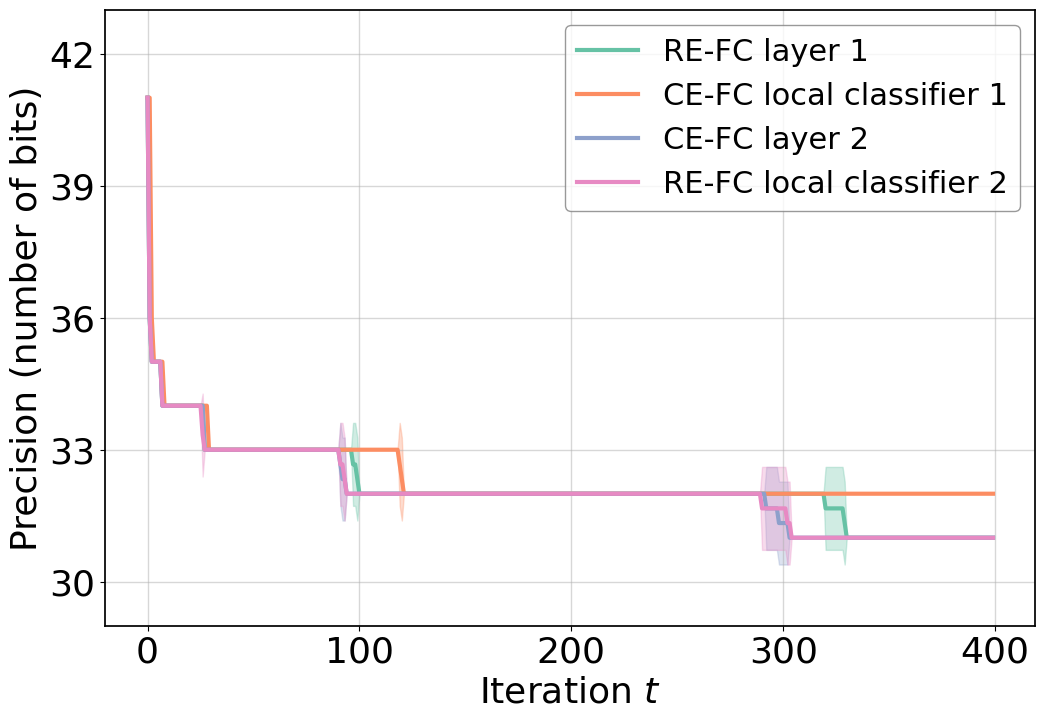

In [10]:
fig, ax = plt.subplots(1, 1, figsize=(12, 8))
ax.set_xlabel(x_label)
ax.set_ylabel(y_label)

# Iterate over each column (layer) to create individual plots for each layer across iterations
for layer, color, label in zip(mean_df.columns, colors, legend_labels):
    # Extract mean and std values for the current layer (column)
    mean_values = mean_df[layer].values  # Mean values for the current layer across iterations
    std_values = std_df[layer].values    # Standard deviation values for the current layer across iterations

    # Define the confidence bounds
    lower_bound = mean_values - std_values * 2
    upper_bound = mean_values + std_values * 2

    # Plot the mean values and the confidence bounds
    plt.plot(mean_df.index, mean_values, label=label, linewidth=3, color=color)
    plt.fill_between(mean_df.index, lower_bound, upper_bound, alpha=0.3, color=color)
    
# ax.xaxis.set_tick_params(rotation=45)
ax.tick_params(axis='x')
ax.tick_params(axis='y')  
# ax.set_yscale('log')  
ax.set_ylim(29, 43)
ax.set_yticks(list(range(30, 44, 3)))

legend = ax.legend()
frame = legend.get_frame()
frame.set_edgecolor('0.5')
ax.grid(linewidth=1, alpha=0.5, axis='both')

In [11]:
from pathlib import Path

fn = Path(f'out/layers_precision.pdf')
fig.savefig(fn, bbox_inches='tight')